In [1]:
import xarray as xr

%config InlineBackend.figure_format='retina'
xr.set_options(display_style="text")
import os 

In [24]:
daily_files_path = "../data/daily"
all_files = os.listdir(daily_files_path)

In [28]:
filepath = os.path.join(daily_files_path, all_files[1])

In [ ]:
ds_all = xr.open_dataset(filepath, chunks={"time": 30, "lat": 180, "lon": 180})

for filename in all_files[1:]:
    filepath = os.path.join(daily_files_path, filename)
    if os.path.splitext(filepath)[1] == '.nc':
        # ds = xr.open_dataset(filepath, engine="netcdf4")
        try:
            ds = xr.open_dataset(filepath, chunks={"time": 30, "lat": 180, "lon": 180})
            print(ds.sst.shape)
            ds_all = xr.concat([ds_all, ds], dim="time")
        except:
            print(filepath) ## error with year 1986


In [31]:
ds_sorted = ds_all.sortby('time')
ds_sorted = ds_sorted.chunk({'time':"auto"})
# ds_sorted.to_zarr("../data/sst_daily.zarr", mode="w")

In [2]:
ds_zarr = xr.open_zarr('../data/sst_daily.zarr')

In [3]:
ds_zarr

<xarray.Dataset> Size: 63GB
Dimensions:  (time: 15097, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 121kB 1981-09-01 1981-09-02 ... 2023-12-31
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    sst      (time, lat, lon) float32 63GB dask.array<chunksize=(1008, 180, 180), meta=np.ndarray>
Attributes:
    Conventions:    CF-1.5
    title:          NOAA/NCEI 1/4 Degree Daily Optimum Interpolation Sea Surf...
    institution:    NOAA/National Centers for Environmental Information
    source:         NOAA/NCEI https://www.ncei.noaa.gov/data/sea-surface-temp...
    References:     https://www.psl.noaa.gov/data/gridded/data.noaa.oisst.v2....
    dataset_title:  NOAA Daily Optimum Interpolation Sea Surface Temperature
    version:        Version 2.1
    comment:        Reynolds, et al.(2007) Daily High-Resolution-Blended Anal...

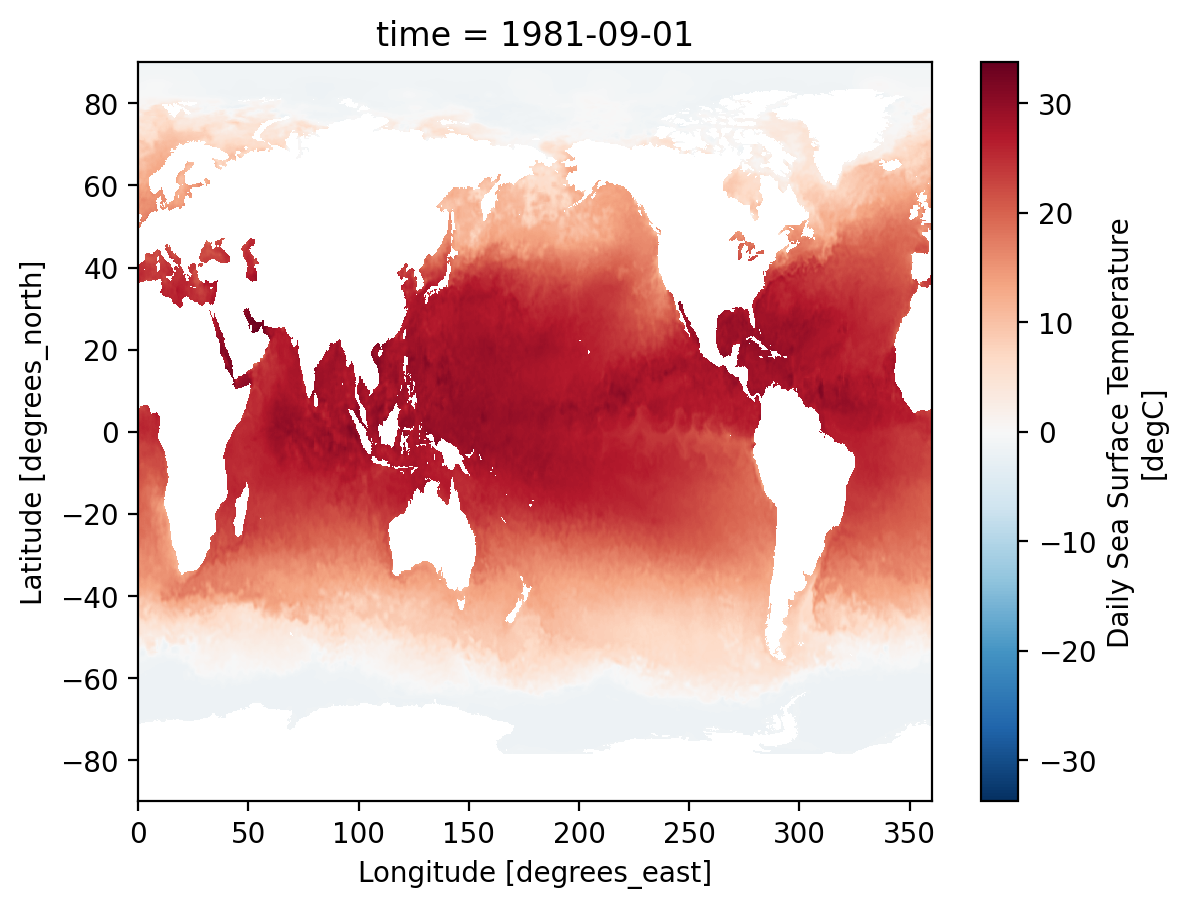

In [4]:
ds_zarr.sst[0].plot()

In [23]:
ds_init = xr.open_dataset('../data/cache/initial_map_high_res.nc', engine="netcdf4",)
# ds_init["time"] = xr.decode_cf(ds_init).time

# sst = ds_init.sst
# sst_grouped = sst.groupby("time.month")
# tos_std = sst_grouped.std(dim="time")
# initial_map = tos_std.mean(dim="month")


In [24]:
ds_init.sst

<xarray.DataArray 'sst' (lat: 720, lon: 1440)> Size: 4MB
[1036800 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Attributes:
    long_name:      Weekly Mean of Sea Surface Temperature
    units:          degC
    valid_range:    [-3. 45.]
    precision:      2.0
    dataset:        NOAA High-resolution Blended Analysis
    var_desc:       Sea Surface Temperature
    level_desc:     Surface
    statistic:      Weekly Mean
    parent_stat:    Individual Observations
    standard_name:  sea_surface_temperature
    actual_range:   [-1.8000001 32.14     ]

In [25]:
import matplotlib.pyplot as plt

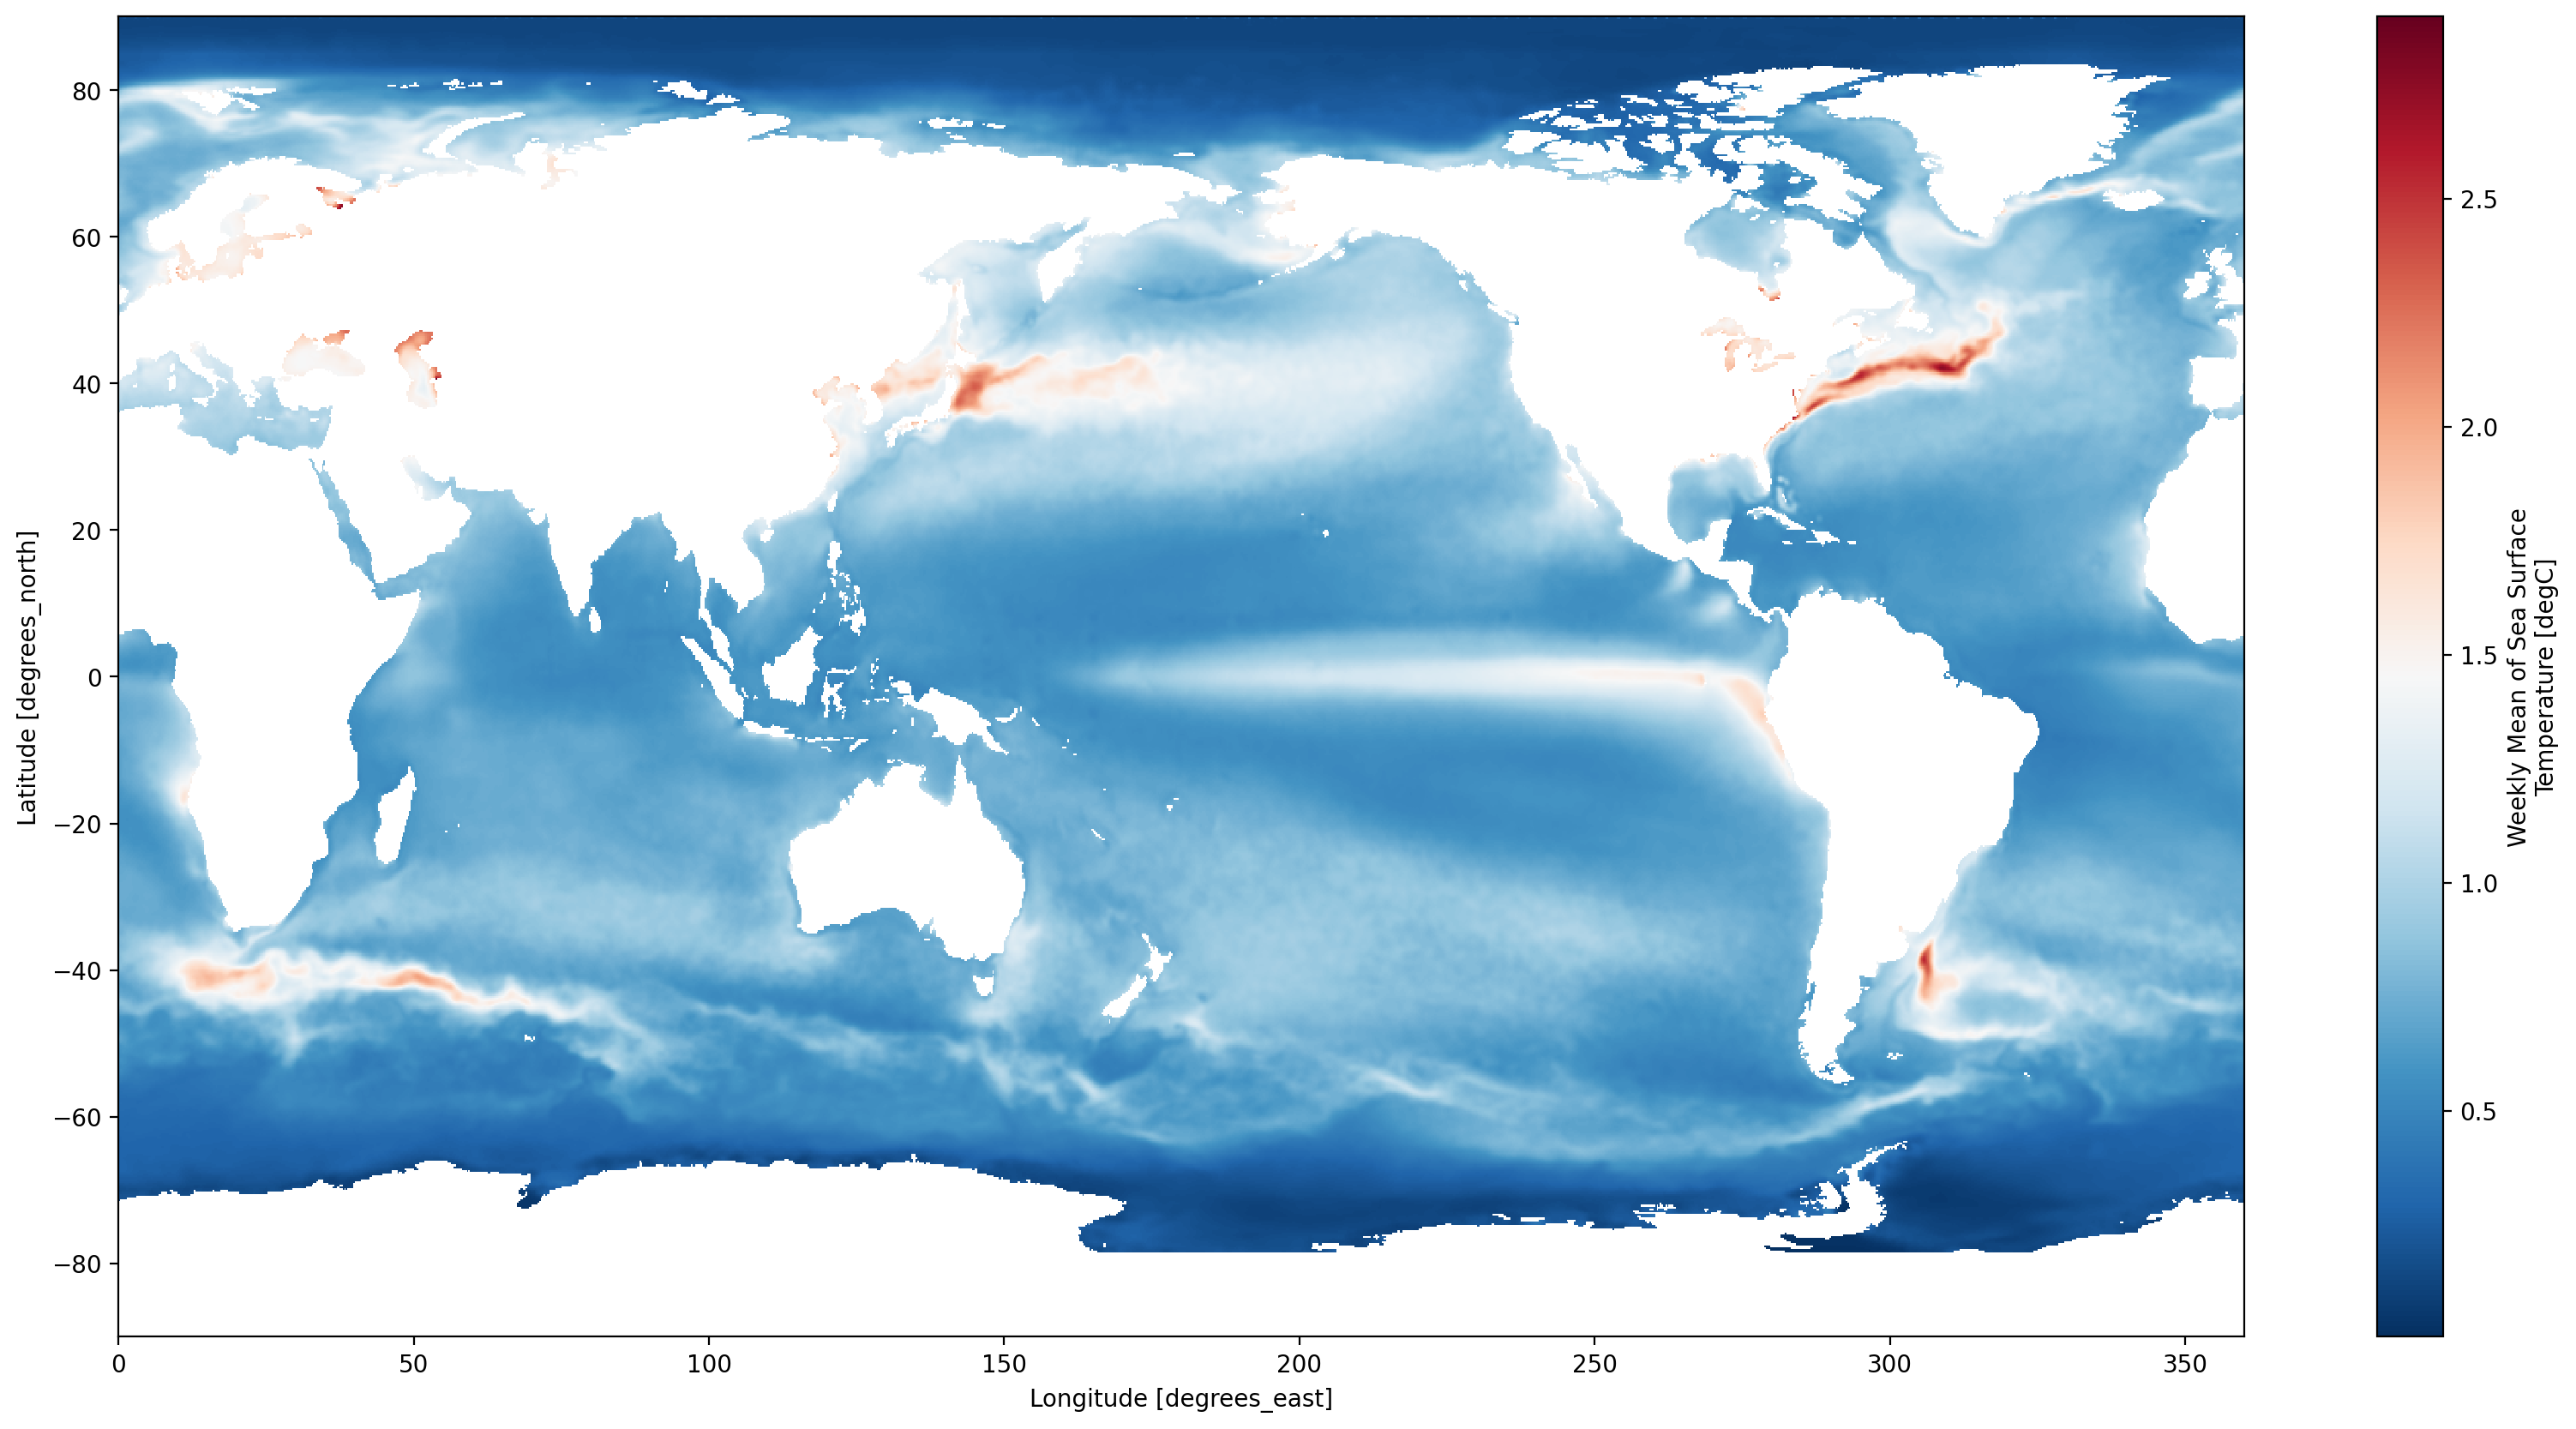

In [30]:
plt.figure(figsize=(20,10))
ds_init['sst'].plot(center=False, cmap='RdBu_r')
plt.savefig('highres_anomaly_map_2.png',dpi=1280)